# **2. PreProcessing & Feature Enginerring**

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
import zipfile
from pathlib import Path

%matplotlib inline
sns.set_style('darkgrid')



In [2]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [3]:
# Read cleaned dataset from previous notebook

clean_files = []
parent_path = Path.cwd().parent
data_path = parent_path.joinpath("data", "processed")
for file in data_path.rglob("*.csv"):
    clean_files.append(file)
    print(file.name)
    print(clean_files.index(file), " ", file)

test_cleaned.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\data\processed\test_cleaned.csv
train_cleaned.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\data\processed\train_cleaned.csv


In [4]:
print("Loading Cleaned data....")
train_cleaned = pd.read_csv(clean_files[1])
test_cleaned = pd.read_csv(clean_files[0])
test_id = test_cleaned['Id']

Loading Cleaned data....


In [6]:
train_cleaned.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No,No,No,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,No,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No,No,No,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No,No,No,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,No,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No,No,No,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No,No,No,0,12,2008,WD,Normal,250000


#### **1. Feature Engineering**

In [79]:
# Store features in different groups based on their data type

ordinal_num_var = ['OverallQual', 'OverallCond', 'BsmtFullBath','BsmtHalfBath',
                   'FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageCars']

convert_cat_var = ['MSSubClass', 'YrSold', 'MoSold']

Year_var = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

numeric_var = [col for col in train_cleaned.select_dtypes(include=np.number).columns 
               if col not in ordinal_num_var + convert_cat_var + Year_var and col not in 
               ['SalePrice', 'Id']]

# ordinal categorical features based on quality and condition
ordinal_qual_cond_var = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                         'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']

# ordinal categorical features based on basement and finish types
ordinal_bsmt_fin_var = ['BsmtFinType1', 'BsmtFinType2', 'BsmtExposure', 'GarageFinish']

# ordinal features based on functional and utility 
ordinal_fun_util_var = ['LotShape', 'Fence', 'Functional', 'Utilities']

# nominal categorical features
cat_var = [col for col in train_cleaned.select_dtypes(include=['object']).columns 
           if col not in ordinal_qual_cond_var + ordinal_bsmt_fin_var + ordinal_fun_util_var]
           

In [52]:
def feature_engineering(df):

    result = df.copy()

    """
    Create new features : In this step I will create new features from weaker features in the training data. 
    For example, the surface area of each floor has low correlation with house price; 
    however, when we sum them up, the relationship becomes much stronger. 
    In fact, TotalSqFeet becomes the strongest feature in the dataset. 
    The new features I will create are total square feet, total number of bathrooms, age of the house, 
    whether the house was remodeled, and whether the house was sold in the same year it was built.
    """
    # Create new feature 'TotalSF' as the sum of 'TotalBsmtSF', '1stFlrSF', and '2ndFlrSF' 
    result['TotalSF'] = result['TotalBsmtSF'] + result['1stFlrSF'] + result['2ndFlrSF']
    
    # Create new feature 'TotalBath' as the sum of all bathroom-related features
    result['TotalBath'] = (result['FullBath'] + 0.5 * result['HalfBath'] + 
                       result['BsmtFullBath'] + 0.5 * result['BsmtHalfBath'])
    
    # Create new feature 'TotalPorchSF' as the sum of all porch-related features
    result['TotalPorchSF'] = (result['OpenPorchSF'] + result['EnclosedPorch'] + 
                          result['3SsnPorch'] + result['ScreenPorch'] + result['WoodDeckSF'])
    
    # Create new feature 'HouseAge' as the difference between the year sold and the year built
    result['HouseAge'] = result['YrSold'] - result['YearBuilt']

    # Create new feature 'Remodeled' to indicate whether the house was remodeled and remodeled age
    result['Remodeled'] = (result['YearRemodAdd'] != result['YearBuilt']).astype('bool')
    result['RemodeledAge'] = result['YrSold'] - result['YearRemodAdd']

    # Create new feature 'SameYearSale' to indicate whether the house was sold in the same year it was built
    result['SameYearSale'] = (result['YrSold'] == result['YearBuilt']).astype('bool')

    # Create new feature 'BathToBedRatio' as the ratio of total bathrooms to total bedrooms
    result['BathToBedRatio'] = result['TotalBath'] / (result['BedroomAbvGr'] + 1)  # Adding 1 to avoid division by zero

    # Has Amenities flags
    result['HasFireplace'] = (result['Fireplaces'] > 0).astype('bool')
    result['HasGarage'] = (result['GarageCars'] > 0).astype('bool')
    result['HasBasement'] = (result['TotalBsmtSF'] > 0).astype('bool')
    result['HasPorch'] = (result['OpenPorchSF'] > 0).astype('bool')

    """ Label Encoding for ordinal categorical features """
    # 1. Quality and Condition features
    ordinal_qual_cond_var = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                         'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
    for col in ordinal_qual_cond_var:
        qual_map = {'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
        result[col] = result[col].map(lambda x: qual_map.get(x, 0))  # Map to numeric, default to 0 for 'No' or missing

    # 2. Basement and Finish features
    ordinal_bsmt_fin_var = ['BsmtFinType1', 'BsmtFinType2', 'BsmtExposure', 'GarageFinish']
    finish_scale = {'No': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
    result['BsmtFinType1'] = result['BsmtFinType1'].map(lambda x: finish_scale.get(x, 0))
    result['BsmtFinType2'] = result['BsmtFinType2'].map(lambda x: finish_scale.get(x, 0))
    exposure_scale = {'No': 0, 'Mn': 1, 'Av': 2, 'Gd': 3}
    result['BsmtExposure'] = result['BsmtExposure'].map(lambda x: exposure_scale.get(x, 0))
    result['GarageFinish'] = result['GarageFinish'].map({'No': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})

    # 3. Functional and Utility features
    ordinal_fun_util_var = ['LotShape', 'Fence', 'Functional', 'Utilities']
    result['LotShape'] = result['LotShape'].map({"IR3" : 1, "IR2" : 2, "IR1" : 3, "Reg" : 4})
    result['Fence'] = result['Fence'].map({"No": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4})
    result['Functional'] = result['Functional'].map({"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min1": 6, "Min2": 7, "Typ": 8})
    result['Utilities'] = result['Utilities'].map({"ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4})

    # Non-linear relationships
    result['OverallQualSquared'] = result['OverallQual'] ** 2

    # Feature Interactions
    result['LivAreaQual'] = result['GrLivArea'] * result['OverallQual']
    result['QualCond'] = result['OverallQual'] * result['OverallCond']

    return result


# Applying feature engineering to both train and test datasets
print("="*20, "Applying feature engineering to datasets...", "="*20)
train_processed = feature_engineering(train_cleaned)
test_processed = feature_engineering(test_cleaned)

==================== Applying feature engineering to datasets... ====================


In [96]:
# Compute neighborhood-wise median sale price and create a new feature 'NeighborhoodMedianPrice' (only using training dataset)
neighborhood_price = train_processed.groupby('Neighborhood')['SalePrice'].median()
train_processed['NeighborhoodMedianPrice'] = train_processed['Neighborhood'].map(neighborhood_price)

# For test data, map the same neighborhood values from training data
test_processed['NeighborhoodMedianPrice'] = test_processed['Neighborhood'].map(neighborhood_price)

In [ ]:
train_data = train_cleaned.copy()
train_data['TotalSF'] = train_data['TotalBsmtSF'] + train_data['1stFlrSF'] + train_data['2ndFlrSF']
train_data['LogTotalSF'] = np.log1p(train_data['TotalSF'])
train_data[['TotalSF', 'LogTotalSF', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF', 'SalePrice']].corr()#(train_data['SalePrice'])#.sort_values(ascending=False)
skewed = train_processed[numeric_var].skew()
train_processed[skewed[skewed > 0.5].index.tolist()].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LotFrontage    1460 non-null   float64
 1   LotArea        1460 non-null   int64  
 2   MasVnrArea     1460 non-null   float64
 3   BsmtFinSF1     1460 non-null   int64  
 4   BsmtFinSF2     1460 non-null   int64  
 5   BsmtUnfSF      1460 non-null   int64  
 6   TotalBsmtSF    1460 non-null   int64  
 7   1stFlrSF       1460 non-null   int64  
 8   2ndFlrSF       1460 non-null   int64  
 9   LowQualFinSF   1460 non-null   int64  
 10  GrLivArea      1460 non-null   int64  
 11  WoodDeckSF     1460 non-null   int64  
 12  OpenPorchSF    1460 non-null   int64  
 13  EnclosedPorch  1460 non-null   int64  
 14  3SsnPorch      1460 non-null   int64  
 15  ScreenPorch    1460 non-null   int64  
 16  PoolArea       1460 non-null   int64  
 17  MiscVal        1460 non-null   int64  
dtypes: float

In [99]:
numeric_feat = [col for col in train_processed.select_dtypes(include=np.number).columns 
               if col not in ordinal_num_var + convert_cat_var + Year_var and col not in 
               ['SalePrice', 'Id']]

skewed = train_processed[numeric_feat].skew()
train_processed[skewed[skewed > 0.5].index.tolist()].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   LotFrontage              1460 non-null   float64
 1   LotArea                  1460 non-null   int64  
 2   MasVnrArea               1460 non-null   float64
 3   ExterQual                1460 non-null   int64  
 4   ExterCond                1460 non-null   int64  
 5   BsmtExposure             1460 non-null   int64  
 6   BsmtFinSF1               1460 non-null   int64  
 7   BsmtFinType2             1460 non-null   int64  
 8   BsmtFinSF2               1460 non-null   int64  
 9   BsmtUnfSF                1460 non-null   int64  
 10  TotalBsmtSF              1460 non-null   int64  
 11  1stFlrSF                 1460 non-null   int64  
 12  2ndFlrSF                 1460 non-null   int64  
 13  LowQualFinSF             1460 non-null   int64  
 14  GrLivArea               

In [102]:
h = train_processed[['TotalSF', 'TotalBath', 'TotalPorchSF',
       'HouseAge', 'Remodeled', 'RemodeledAge', 'SameYearSale',
       'BathToBedRatio', 'HasFireplace', 'HasGarage', 'HasBasement',
       'HasPorch', 'OverallQualSquared', 'LivAreaQual', 'QualCond', 'NeighborhoodMedianPrice']].skew()
h[h > 2]

SameYearSale      4.460855
BathToBedRatio    2.071479
LivAreaQual       2.018926
dtype: float64

In [108]:
train_df = train_processed.copy()
i = train_df[numeric_feat].skew().round(4).sort_values(ascending=False) 
display(i[i > 0.5])
print(len(i.index))
for col in i[i > 0.5].index.tolist():
   train_df[col] = np.log1p(train_df[col])

MiscVal                    24.4768
PoolQC                     15.9586
PoolArea                   14.8284
LotArea                    12.2077
3SsnPorch                  10.3043
LowQualFinSF                9.0113
BsmtFinSF2                  4.2553
ScreenPorch                 4.1222
BsmtFinType2                3.2970
EnclosedPorch               3.0899
MasVnrArea                  2.6776
OpenPorchSF                 2.3643
LotFrontage                 2.2130
BathToBedRatio              2.0715
LivAreaQual                 2.0189
Fence                       1.8072
TotalSF                     1.7767
BsmtFinSF1                  1.6855
WoodDeckSF                  1.5414
TotalBsmtSF                 1.5243
ExterCond                   1.3972
1stFlrSF                    1.3768
GrLivArea                   1.3666
BsmtExposure                1.2151
TotalPorchSF                1.1023
NeighborhoodMedianPrice     1.0178
BsmtUnfSF                   0.9203
OverallQualSquared          0.8676
ExterQual           

47


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [109]:
j = train_df[numeric_feat].skew().round(4).sort_values(ascending=False)
display(len(j[j > 0.5]))

c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


14

In [104]:
skewed = train_data[numeric_var].skew().round(4)
#train_data[skewed[skewed > 0.5].index.tolist()].info()
g = skewed[skewed > 2].index.tolist()
train_processed[g + ['SalePrice', 'TotalPorchSF']].corr()['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
TotalPorchSF     0.390993
ScreenPorch      0.111447
PoolArea         0.092404
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
MiscVal         -0.021190
LowQualFinSF    -0.025606
EnclosedPorch   -0.128578
Name: SalePrice, dtype: float64

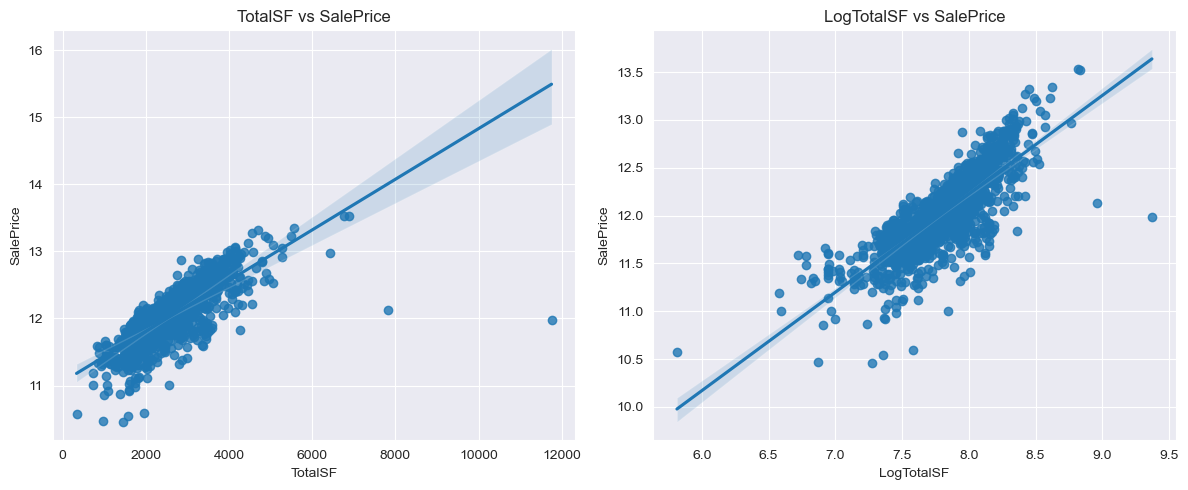

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(x='TotalSF', y=np.log1p(train_processed['SalePrice']), data=train_processed, ax=axes[0])
axes[0].set_title('TotalSF vs SalePrice')
sns.regplot(x='LogTotalSF', y=np.log1p(train_data['SalePrice']), data=train_data, ax=axes[1])
axes[1].set_title('LogTotalSF vs SalePrice')

plt.tight_layout()
plt.show()

In [37]:
u = (train_data['OpenPorchSF'] > 0).astype('bool')
u.unique()

array([ True, False])